## Regression with Categorical Outcome Variable: NBA Data Set

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
from IPython.display import display, HTML

display(HTML(data="""
<style>
    div#notebook-container    { width: 95%; }
    div#menubar-container     { width: 65%; }
    div#maintoolbar-container { width: 99%; }
</style>
"""))

In [3]:
#Import Data
NBA = pd.read_csv("Assignment Data/NBA_Games2.csv")

In [4]:
NBA.head()

,CITY,TEAM_NAME,TEAM_ID,NICKNAME,STATE,YEAR_FOUNDED,SEASON_ID,TEAM_ABBREVIATION,GAME_ID,GAME_DATE,...,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS,WIN
0,Atlanta,Atlanta Hawks,1610612737,Hawks,Atlanta,1949,22019,ATL,1521900072,2019-07-12,...,13,23,36,14,15,3,12,24,8.0,1
1,Atlanta,Atlanta Hawks,1610612737,Hawks,Atlanta,1949,22019,ATL,1521900060,2019-07-11,...,9,28,37,19,10,8,22,25,-5.0,0
2,Atlanta,Atlanta Hawks,1610612737,Hawks,Atlanta,1949,22019,ATL,1521900042,2019-07-09,...,7,27,34,17,5,5,18,21,18.2,1
3,Atlanta,Atlanta Hawks,1610612737,Hawks,Atlanta,1949,22019,ATL,1521900023,2019-07-07,...,9,27,36,7,7,10,18,28,-24.0,0
4,Atlanta,Atlanta Hawks,1610612737,Hawks,Atlanta,1949,22019,ATL,1521900013,2019-07-06,...,9,30,39,13,11,6,13,21,2.0,0


In [13]:
NBA_2017 = NBA[(NBA["SEASON_ID"] == 22017) & (NBA["GAME_ID"] < 1000000000)]
NBA_2017.head()

,CITY,TEAM_NAME,TEAM_ID,NICKNAME,STATE,YEAR_FOUNDED,SEASON_ID,TEAM_ABBREVIATION,GAME_ID,GAME_DATE,...,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS,WIN
101,Atlanta,Atlanta Hawks,1610612737,Hawks,Atlanta,1949,22017,ATL,21701214,2018-04-10,...,8,31,39,27,10,3,10,24,-8.0,0
102,Atlanta,Atlanta Hawks,1610612737,Hawks,Atlanta,1949,22017,ATL,21701202,2018-04-08,...,5,32,37,23,7,4,13,19,6.0,1
103,Atlanta,Atlanta Hawks,1610612737,Hawks,Atlanta,1949,22017,ATL,21701184,2018-04-06,...,7,43,50,24,5,5,18,22,6.0,1
104,Atlanta,Atlanta Hawks,1610612737,Hawks,Atlanta,1949,22017,ATL,21701172,2018-04-04,...,10,38,48,20,5,6,15,16,-29.0,0
105,Atlanta,Atlanta Hawks,1610612737,Hawks,Atlanta,1949,22017,ATL,21701158,2018-04-03,...,12,37,49,24,10,1,15,15,-3.0,0


In [15]:
NBA_2017.columns.to_list()

['CITY',
 'TEAM_NAME',
 'TEAM_ID',
 'NICKNAME',
 'STATE',
 'YEAR_FOUNDED',
 'SEASON_ID',
 'TEAM_ABBREVIATION',
 'GAME_ID',
 'GAME_DATE',
 'MATCHUP',
 'WL',
 'MIN',
 'PTS',
 'FGM',
 'FGA',
 'FG_PCT',
 'FG3M',
 'FG3A',
 'FG3_PCT',
 'FTM',
 'FTA',
 'FT_PCT',
 'OREB',
 'DREB',
 'REB',
 'AST',
 'STL',
 'BLK',
 'TOV',
 'PF',
 'PLUS_MINUS',
 'WIN']

In [17]:
NBA_2017[['MATCHUP','PTS']]

,MATCHUP,PTS
101,ATL vs. PHI,113
102,ATL @ BOS,112
103,ATL @ WAS,103
104,ATL vs. MIA,86
105,ATL @ MIA,98
...,...,...
18106,CHA vs. HOU,93
18107,CHA vs. DEN,110
18108,CHA @ MIL,94
18109,CHA vs. ATL,109


In [18]:
NBA_2017['home_away'] = np.where(NBA_2017['MATCHUP'].str.contains('vs.', regex=False, na=False), 1, 0)
NBA_2017.head()

,CITY,TEAM_NAME,TEAM_ID,NICKNAME,STATE,YEAR_FOUNDED,SEASON_ID,TEAM_ABBREVIATION,GAME_ID,GAME_DATE,...,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS,WIN,home_away
101,Atlanta,Atlanta Hawks,1610612737,Hawks,Atlanta,1949,22017,ATL,21701214,2018-04-10,...,31,39,27,10,3,10,24,-8.0,0,1
102,Atlanta,Atlanta Hawks,1610612737,Hawks,Atlanta,1949,22017,ATL,21701202,2018-04-08,...,32,37,23,7,4,13,19,6.0,1,0
103,Atlanta,Atlanta Hawks,1610612737,Hawks,Atlanta,1949,22017,ATL,21701184,2018-04-06,...,43,50,24,5,5,18,22,6.0,1,0
104,Atlanta,Atlanta Hawks,1610612737,Hawks,Atlanta,1949,22017,ATL,21701172,2018-04-04,...,38,48,20,5,6,15,16,-29.0,0,1
105,Atlanta,Atlanta Hawks,1610612737,Hawks,Atlanta,1949,22017,ATL,21701158,2018-04-03,...,37,49,24,10,1,15,15,-3.0,0,0


In [19]:
NBA_2017 = NBA_2017.sort_values(by='GAME_ID')
NBA_2017.head(10)

,CITY,TEAM_NAME,TEAM_ID,NICKNAME,STATE,YEAR_FOUNDED,SEASON_ID,TEAM_ABBREVIATION,GAME_ID,GAME_DATE,...,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS,WIN,home_away
1501,Cleveland,Cleveland Cavaliers,1610612739,Cavaliers,Ohio,1970,22017,CLE,21700001,2017-10-17,...,41,50,19,3,4,17,25,3.0,1,1
846,Boston,Boston Celtics,1610612738,Celtics,Massachusetts,1946,22017,BOS,21700001,2017-10-17,...,37,46,24,11,4,10,24,-3.0,0,0
5328,Houston,Houston Rockets,1610612745,Rockets,Texas,1967,22017,HOU,21700002,2017-10-17,...,33,43,28,9,5,12,16,1.0,1,0
4630,Golden State,Golden State Warriors,1610612744,Warriors,California,1946,22017,GSW,21700002,2017-10-17,...,35,41,34,5,9,17,25,-1.0,0,1
18110,Charlotte,Charlotte Hornets,1610612766,Hornets,North Carolina,1988,22017,CHA,21700003,2017-10-18,...,44,47,16,4,3,17,15,-12.0,0,0
17522,Detroit,Detroit Pistons,1610612765,Pistons,Michigan,1948,22017,DET,21700003,2017-10-18,...,38,47,24,14,3,8,21,12.0,1,1
10535,Indiana,Indiana Pacers,1610612754,Pacers,Indiana,1976,22017,IND,21700004,2017-10-18,...,33,47,29,12,9,14,25,9.0,1,1
8731,Brooklyn,Brooklyn Nets,1610612751,Nets,New York,1976,22017,BKN,21700004,2017-10-18,...,32,43,22,7,2,20,25,-9.0,0,0
6826,Miami,Miami Heat,1610612748,Heat,Florida,1988,22017,MIA,21700005,2017-10-18,...,33,44,27,6,4,13,20,-7.0,0,0
9946,Orlando,Orlando Magic,1610612753,Magic,Florida,1989,22017,ORL,21700005,2017-10-18,...,39,50,22,8,9,14,18,7.0,1,1


In [21]:
NBA_2017_game = NBA_2017.groupby("GAME_ID")["PTS"].sum().reset_index()
NBA_2017_game.head()

,GAME_ID,PTS
0,21700001,201
1,21700002,243
2,21700003,192
3,21700004,271
4,21700005,225


In [23]:
NBA_2017 = NBA_2017[['TEAM_ID','TEAM_ABBREVIATION','GAME_ID','GAME_DATE','MATCHUP','PTS','WIN','home_away']]
NBA_2017.head()

,TEAM_ID,TEAM_ABBREVIATION,GAME_ID,GAME_DATE,MATCHUP,PTS,WIN,home_away
1501,1610612739,CLE,21700001,2017-10-17,CLE vs. BOS,102,1,1
846,1610612738,BOS,21700001,2017-10-17,BOS @ CLE,99,0,0
5328,1610612745,HOU,21700002,2017-10-17,HOU @ GSW,122,1,0
4630,1610612744,GSW,21700002,2017-10-17,GSW vs. HOU,121,0,1
18110,1610612766,CHA,21700003,2017-10-18,CHA @ DET,90,0,0


In [24]:
NBA_2017 = pd.merge(NBA_2017,NBA_2017_game,on=['GAME_ID'])
NBA_2017.head()

,TEAM_ID,TEAM_ABBREVIATION,GAME_ID,GAME_DATE,MATCHUP,PTS_x,WIN,home_away,PTS_y
0,1610612739,CLE,21700001,2017-10-17,CLE vs. BOS,102,1,1,201
1,1610612738,BOS,21700001,2017-10-17,BOS @ CLE,99,0,0,201
2,1610612745,HOU,21700002,2017-10-17,HOU @ GSW,122,1,0,243
3,1610612744,GSW,21700002,2017-10-17,GSW vs. HOU,121,0,1,243
4,1610612766,CHA,21700003,2017-10-18,CHA @ DET,90,0,0,192


In [25]:
NBA_2017 = NBA_2017.rename(columns={
    'PTS_x': 'PTS_FOR', 
    'PTS_y': 'PTS_TOTAL'
})
NBA_2017.head()

,TEAM_ID,TEAM_ABBREVIATION,GAME_ID,GAME_DATE,MATCHUP,PTS_FOR,WIN,home_away,PTS_TOTAL
0,1610612739,CLE,21700001,2017-10-17,CLE vs. BOS,102,1,1,201
1,1610612738,BOS,21700001,2017-10-17,BOS @ CLE,99,0,0,201
2,1610612745,HOU,21700002,2017-10-17,HOU @ GSW,122,1,0,243
3,1610612744,GSW,21700002,2017-10-17,GSW vs. HOU,121,0,1,243
4,1610612766,CHA,21700003,2017-10-18,CHA @ DET,90,0,0,192


In [26]:
NBA_2017['PTS_AGAINST'] = NBA_2017['PTS_TOTAL'] - NBA_2017['PTS_FOR']
NBA_2017.head()

,TEAM_ID,TEAM_ABBREVIATION,GAME_ID,GAME_DATE,MATCHUP,PTS_FOR,WIN,home_away,PTS_TOTAL,PTS_AGAINST
0,1610612739,CLE,21700001,2017-10-17,CLE vs. BOS,102,1,1,201,99
1,1610612738,BOS,21700001,2017-10-17,BOS @ CLE,99,0,0,201,102
2,1610612745,HOU,21700002,2017-10-17,HOU @ GSW,122,1,0,243,121
3,1610612744,GSW,21700002,2017-10-17,GSW vs. HOU,121,0,1,243,122
4,1610612766,CHA,21700003,2017-10-18,CHA @ DET,90,0,0,192,102


In [27]:
NBA_2017['cumPF'] = NBA_2017.groupby(['TEAM_ID'])['PTS_FOR'].apply(lambda x: x.cumsum())
NBA_2017['cumPA'] = NBA_2017.groupby(['TEAM_ID'])['PTS_AGAINST'].apply(lambda x: x.cumsum())
NBA_2017['pyth_wpct'] = NBA_2017['cumPF']**2/(NBA_2017['cumPF']**2 + NBA_2017['cumPA']**2)
NBA_2017.head()

,TEAM_ID,TEAM_ABBREVIATION,GAME_ID,GAME_DATE,MATCHUP,PTS_FOR,WIN,home_away,PTS_TOTAL,PTS_AGAINST,cumPF,cumPA,pyth_wpct
0,1610612739,CLE,21700001,2017-10-17,CLE vs. BOS,102,1,1,201,99,102,99,0.514922
1,1610612738,BOS,21700001,2017-10-17,BOS @ CLE,99,0,0,201,102,99,102,0.485078
2,1610612745,HOU,21700002,2017-10-17,HOU @ GSW,122,1,0,243,121,122,121,0.504115
3,1610612744,GSW,21700002,2017-10-17,GSW vs. HOU,121,0,1,243,122,121,122,0.495885
4,1610612766,CHA,21700003,2017-10-18,CHA @ DET,90,0,0,192,102,90,102,0.437743


In [28]:
NBA_2017

,TEAM_ID,TEAM_ABBREVIATION,GAME_ID,GAME_DATE,MATCHUP,PTS_FOR,WIN,home_away,PTS_TOTAL,PTS_AGAINST,cumPF,cumPA,pyth_wpct
0,1610612739,CLE,21700001,2017-10-17,CLE vs. BOS,102,1,1,201,99,102,99,0.514922
1,1610612738,BOS,21700001,2017-10-17,BOS @ CLE,99,0,0,201,102,99,102,0.485078
2,1610612745,HOU,21700002,2017-10-17,HOU @ GSW,122,1,0,243,121,122,121,0.504115
3,1610612744,GSW,21700002,2017-10-17,GSW vs. HOU,121,0,1,243,122,121,122,0.495885
4,1610612766,CHA,21700003,2017-10-18,CHA @ DET,90,0,0,192,102,90,102,0.437743
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2373,1610612747,LAL,21701228,2018-04-11,LAL @ LAC,115,1,0,115,0,8862,8540,0.518497
2374,1610612757,POR,21701229,2018-04-11,POR vs. UTA,102,1,1,195,93,8661,8043,0.536947
2375,1610612762,UTA,21701229,2018-04-11,UTA @ POR,93,0,0,195,102,8540,7770,0.547105
2376,1610612745,HOU,21701230,2018-04-11,HOU @ SAC,83,0,0,179,96,9213,8089,0.564691


In [29]:
reg1 = smf.ols(formula = 'WIN ~ pyth_wpct', data = NBA_2017).fit()
print(reg1.summary())

                            OLS Regression Results                            
Dep. Variable:                    WIN   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     156.6
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           7.80e-35
Time:                        10:59:16   Log-Likelihood:                -1650.1
No. Observations:                2378   AIC:                             3304.
Df Residuals:                    2376   BIC:                             3316.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.6037      0.168     -9.524      0.0

Text(0.5, 1.0, 'Pythagorean Win % and Win-Record')

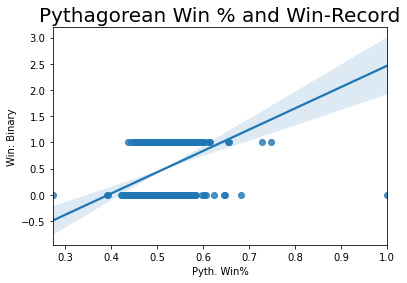

In [30]:
import seaborn as sns
sns.regplot(x = 'pyth_wpct', y ='WIN', data = NBA_2017)
plt.xlabel('Pyth. Win%')
plt.ylabel('Win: Binary')
plt.title("Pythagorean Win % and Win-Record", fontsize=20)

In [31]:
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
import statsmodels.formula.api as smf

Win_Pyth = 'WIN~pyth_wpct'
model = smf.glm(formula = Win_Pyth, data = NBA_2017, family=sm.families.Binomial())
result = model.fit()
print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    WIN   No. Observations:                 2378
Model:                            GLM   Df Residuals:                     2376
Model Family:                Binomial   Df Model:                            1
Link Function:                  logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1563.2
Date:                Thu, 30 Apr 2026   Deviance:                       3126.4
Time:                        11:00:53   Pearson chi2:                 2.30e+04
No. Iterations:                     4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -10.6176      0.884    -12.014      0.0

In [32]:
print("Coefficients")
print(result.params)
print("p-Values")
print(result.pvalues)
print("Dependent variables")
print(result.model.endog_names)

Coefficients
Intercept   -10.617593
pyth_wpct    20.552886
dtype: float64
p-Values
Intercept    3.002543e-33
pyth_wpct    2.763335e-33
dtype: float64
Dependent variables
WIN


In [33]:
fittedProbs = result.predict()
print(fittedProbs[0:10])

[0.49138611 0.34347615 0.43620662 0.39514678 0.16510735 0.71877776
 0.5843523  0.26444999 0.27290071 0.57386908]


In [34]:
# Based on the fitted probabilites of winning, here we create a binary winning variable for 1 indicating Win (Prob. > 50%), 0 indicating lose (Prob. < 50%)
fittedWin = [1 if x > .5 else 0 for x in fittedProbs]
print(fittedWin[0:10])

[0, 0, 0, 0, 0, 1, 1, 0, 0, 1]


In [35]:
from sklearn.metrics import confusion_matrix, classification_report
confusion_matrix(NBA_2017['WIN'], fittedWin)

array([[759, 431],
       [467, 721]])

In [36]:
#Success Rate
(759+721)/(759+721+431+467)

0.6223717409587889

In [45]:
print(classification_report(NBA_2017['WIN'], fittedWin, digits=3))

              precision    recall  f1-score   support

           0      0.619     0.638     0.628      1190
           1      0.626     0.607     0.616      1188

    accuracy                          0.622      2378
   macro avg      0.622     0.622     0.622      2378
weighted avg      0.622     0.622     0.622      2378



In [37]:
Win_Pyth_hm = 'WIN~pyth_wpct + home_away'
model2 = smf.glm(formula=Win_Pyth_hm, data = NBA_2017, family=sm.families.Binomial())
result2 = model2.fit()
print(result2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    WIN   No. Observations:                 2378
Model:                            GLM   Df Residuals:                     2375
Model Family:                Binomial   Df Model:                            2
Link Function:                  logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1531.9
Date:                Thu, 30 Apr 2026   Deviance:                       3063.8
Time:                        11:05:26   Pearson chi2:                 3.62e+04
No. Iterations:                     4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -11.1201      0.902    -12.329      0.0

In [38]:
print("Coefficients")
print(result2.params)
print("p-Values")
print(result2.pvalues)
print("Dependent variables")
print(result2.model.endog_names)



Coefficients
Intercept   -11.120080
pyth_wpct    20.869408
home_away     0.677358
dtype: float64
p-Values
Intercept    6.313810e-35
pyth_wpct    3.111513e-33
home_away    4.172622e-15
dtype: float64
Dependent variables
WIN


In [39]:
#we can fit the model to calculate probabilities of winning on each game
## Here we can print first 10 probabilities, which correspond to the probability of the chance of winning
fittedProbs2 = result2.predict()
print(fittedProbs2[0:10])



[0.57527259 0.26957288 0.35445913 0.47654254 0.12082518 0.78435782
 0.6646974  0.20137981 0.20849536 0.65489467]


In [40]:
# Based on the fitted probabilites of winning, here we create a binary winning variable for 1 indicating Win, 0 indicating lose
fittedWin2 = [1 if x > .5 else 0 for x in fittedProbs2]
print(fittedWin2[0:10])



[1, 0, 0, 0, 0, 1, 1, 0, 0, 1]


In [43]:
from sklearn.metrics import confusion_matrix, classification_report
confusion_matrix(NBA_2017['WIN'], fittedWin2)




array([[773, 417],
       [438, 750]])

In [44]:
print(classification_report(NBA_2017['WIN'], fittedWin2, digits=3))

              precision    recall  f1-score   support

           0      0.638     0.650     0.644      1190
           1      0.643     0.631     0.637      1188

    accuracy                          0.640      2378
   macro avg      0.640     0.640     0.640      2378
weighted avg      0.640     0.640     0.640      2378



In [47]:
NBA17_1st =  NBA_2017[(NBA_2017["GAME_ID"] <= 21700615)]
display(NBA17_1st[0:5])

NBA17_2nd =  NBA_2017[(NBA_2017["GAME_ID"] > 21700615)]
display(NBA17_2nd[0:5])

,TEAM_ID,TEAM_ABBREVIATION,GAME_ID,GAME_DATE,MATCHUP,PTS_FOR,WIN,home_away,PTS_TOTAL,PTS_AGAINST,cumPF,cumPA,pyth_wpct
0,1610612739,CLE,21700001,2017-10-17,CLE vs. BOS,102,1,1,201,99,102,99,0.514922
1,1610612738,BOS,21700001,2017-10-17,BOS @ CLE,99,0,0,201,102,99,102,0.485078
2,1610612745,HOU,21700002,2017-10-17,HOU @ GSW,122,1,0,243,121,122,121,0.504115
3,1610612744,GSW,21700002,2017-10-17,GSW vs. HOU,121,0,1,243,122,121,122,0.495885
4,1610612766,CHA,21700003,2017-10-18,CHA @ DET,90,0,0,192,102,90,102,0.437743


,TEAM_ID,TEAM_ABBREVIATION,GAME_ID,GAME_DATE,MATCHUP,PTS_FOR,WIN,home_away,PTS_TOTAL,PTS_AGAINST,cumPF,cumPA,pyth_wpct
1190,1610612758,SAC,21700616,2018-01-11,SAC vs. LAC,115,0,1,115,0,4009,4021,0.498506
1191,1610612747,LAL,21700617,2018-01-11,LAL vs. SAS,93,1,1,174,81,4366,4177,0.522113
1192,1610612759,SAS,21700617,2018-01-11,SAS @ LAL,81,0,0,174,93,4350,4027,0.538501
1193,1610612762,UTA,21700618,2018-01-12,UTA @ CHA,88,0,0,187,99,4231,4062,0.520370
1194,1610612766,CHA,21700618,2018-01-12,CHA vs. UTA,99,1,1,187,88,4201,4037,0.519900


In [48]:
NBA17_pre = NBA17_1st.groupby(['TEAM_ABBREVIATION'])['WIN','PTS_FOR','PTS_AGAINST'].sum()
display(NBA17_pre[0:9])

,WIN,PTS_FOR,PTS_AGAINST
TEAM_ABBREVIATION,,,
ATL,11,4262,4214
BKN,15,4342,4466
BOS,34,4532,4300
CHA,15,4102,3949
CHI,15,4295,4551
CLE,26,4506,4348
DAL,15,4410,4289
DEN,21,4400,4351
DET,22,4088,3966


In [49]:
NBA17_pos = NBA17_2nd.groupby(['TEAM_ABBREVIATION'])['WIN','PTS_FOR','PTS_AGAINST'].sum()
display(NBA17_pos[0:9])

,WIN,PTS_FOR,PTS_AGAINST
TEAM_ABBREVIATION,,,
ATL,13,4213,4484
BKN,13,4399,4345
BOS,21,3997,3704
CHA,21,4772,4711
CHI,12,4145,4241
CLE,24,4585,4437
DAL,9,3980,4045
DEN,25,4620,4202
DET,17,4421,4360


In [50]:
# Obtain the number of games played by each team for the 1st half of the 2016 regular season
NBA17_pre_GameNum = NBA17_1st.groupby(['TEAM_ABBREVIATION']).size().reset_index(name='game_count')
# Merge total number of games (i.e., NNL_pre_gameNUM) to the dataset
NBA17_pre=pd.merge(NBA17_pre, NBA17_pre_GameNum, on=['TEAM_ABBREVIATION'])
NBA17_pre.head()

,TEAM_ABBREVIATION,WIN,PTS_FOR,PTS_AGAINST,game_count
0,ATL,11,4262,4214,41
1,BKN,15,4342,4466,41
2,BOS,34,4532,4300,44
3,CHA,15,4102,3949,39
4,CHI,15,4295,4551,42


In [51]:
# Obtain the number of games played by each team for the 1st half of the 2016 regular season
NBA17_pos_GameNum = NBA17_2nd.groupby(['TEAM_ABBREVIATION']).size().reset_index(name='game_count')
# Merge total number of games (i.e., NNL_pre_gameNUM) to the dataset
NBA17_pos=pd.merge(NBA17_pos, NBA17_pos_GameNum, on=['TEAM_ABBREVIATION'])
NBA17_pos.head()

,TEAM_ABBREVIATION,WIN,PTS_FOR,PTS_AGAINST,game_count
0,ATL,13,4213,4484,41
1,BKN,13,4399,4345,41
2,BOS,21,3997,3704,38
3,CHA,21,4772,4711,43
4,CHI,12,4145,4241,40


In [52]:
NBA17_pre['win_pct_pre']=NBA17_pre['WIN']/NBA17_pre['game_count']
NBA17_pre['pyth_wpct_pre']=NBA17_pre['PTS_FOR']**2/(NBA17_pre['PTS_FOR']**2+NBA17_pre['PTS_AGAINST']**2)

NBA17_pre.head()

,TEAM_ABBREVIATION,WIN,PTS_FOR,PTS_AGAINST,game_count,win_pct_pre,pyth_wpct_pre
0,ATL,11,4262,4214,41,0.268293,0.505663
1,BKN,15,4342,4466,41,0.365854,0.485925
2,BOS,34,4532,4300,44,0.772727,0.526250
3,CHA,15,4102,3949,39,0.384615,0.518997
4,CHI,15,4295,4551,42,0.357143,0.471085


In [63]:
NBA17_pre.corr()

,WIN,PTS_FOR,PTS_AGAINST,game_count,win_pct_pre,pyth_wpct_pre
WIN,1.000000,0.617275,-0.105255,0.297715,0.994729,0.708397
PTS_FOR,0.617275,1.000000,0.487747,0.511520,0.588240,0.494816
PTS_AGAINST,-0.105255,0.487747,1.000000,0.422528,-0.141870,-0.516547
game_count,0.297715,0.511520,0.422528,1.000000,0.203000,0.084769
win_pct_pre,0.994729,0.588240,-0.141870,0.203000,1.000000,0.716270
pyth_wpct_pre,0.708397,0.494816,-0.516547,0.084769,0.716270,1.000000


In [55]:
NBA17_pos['win_pct_pos']=NBA17_pos['WIN']/NBA17_pos['game_count']
NBA17_pos['pyth_wpct_pos']=NBA17_pos['PTS_FOR']**2/(NBA17_pos['PTS_FOR']**2+NBA17_pos['PTS_AGAINST']**2)

NBA17_pos.head()

,TEAM_ABBREVIATION,WIN,PTS_FOR,PTS_AGAINST,game_count,win_pct_pos,pyth_wpct_pos
0,ATL,13,4213,4484,41,0.317073,0.468870
1,BKN,13,4399,4345,41,0.317073,0.506175
2,BOS,21,3997,3704,38,0.552632,0.537992
3,CHA,21,4772,4711,43,0.488372,0.506432
4,CHI,12,4145,4241,40,0.300000,0.488554


In [64]:
NBA17_pos.corr()

,WIN_x,PTS_FOR_x,PTS_AGAINST_x,game_count_x,win_pct_pos,pyth_wpct_pos,WIN_y,PTS_FOR_y,PTS_AGAINST_y,game_count_y,win_pct_pre,pyth_wpct_pre
WIN_x,1.000000,0.704427,-0.330019,0.328121,0.997026,0.920741,0.521925,0.282508,-0.220638,-0.328121,0.570684,0.496720
PTS_FOR_x,0.704427,1.000000,0.375386,0.720640,0.664308,0.535430,0.164656,0.048121,-0.240071,-0.720640,0.243459,0.284840
PTS_AGAINST_x,-0.330019,0.375386,1.000000,0.548309,-0.378309,-0.581238,-0.440428,-0.297001,-0.121211,-0.548309,-0.397816,-0.171418
game_count_x,0.328121,0.720640,0.548309,1.000000,0.258436,0.133281,-0.297715,-0.511520,-0.422528,-1.000000,-0.203000,-0.084769
win_pct_pos,0.997026,0.664308,-0.378309,0.258436,1.000000,0.930109,0.560463,0.322581,-0.203527,-0.258436,0.602633,0.519085
pyth_wpct_pos,0.920741,0.535430,-0.581238,0.133281,0.930109,1.000000,0.549620,0.306101,-0.112573,-0.133281,0.579529,0.411840
WIN_y,0.521925,0.164656,-0.440428,-0.297715,0.560463,0.549620,1.000000,0.617275,-0.105255,0.297715,0.994729,0.708397
PTS_FOR_y,0.282508,0.048121,-0.297001,-0.511520,0.322581,0.306101,0.617275,1.000000,0.487747,0.511520,0.588240,0.494816
PTS_AGAINST_y,-0.220638,-0.240071,-0.121211,-0.422528,-0.203527,-0.112573,-0.105255,0.487747,1.000000,0.422528,-0.141870,-0.516547
game_count_y,-0.328121,-0.720640,-0.548309,-1.000000,-0.258436,-0.133281,0.297715,0.511520,0.422528,1.000000,0.203000,0.084769


In [56]:
NBA17_pos=pd.merge(NBA17_pos, NBA17_pre, on=['TEAM_ABBREVIATION'])
NBA17_pos.head()

,TEAM_ABBREVIATION,WIN_x,PTS_FOR_x,PTS_AGAINST_x,game_count_x,win_pct_pos,pyth_wpct_pos,WIN_y,PTS_FOR_y,PTS_AGAINST_y,game_count_y,win_pct_pre,pyth_wpct_pre
0,ATL,13,4213,4484,41,0.317073,0.468870,11,4262,4214,41,0.268293,0.505663
1,BKN,13,4399,4345,41,0.317073,0.506175,15,4342,4466,41,0.365854,0.485925
2,BOS,21,3997,3704,38,0.552632,0.537992,34,4532,4300,44,0.772727,0.526250
3,CHA,21,4772,4711,43,0.488372,0.506432,15,4102,3949,39,0.384615,0.518997
4,CHI,12,4145,4241,40,0.300000,0.488554,15,4295,4551,42,0.357143,0.471085


Text(0.5, 1.0, 'Correlation: Pre-win% vs Post-win%')

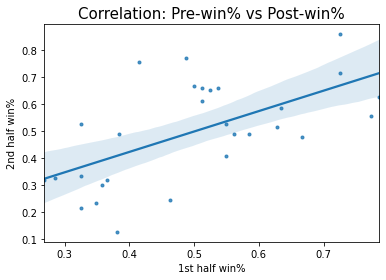

In [57]:
# Let's plot the variables and fit the model
sns.regplot(x='win_pct_pre', y='win_pct_pos', data=NBA17_pos,  marker='.')
plt.xlabel('1st half win%')
plt.ylabel('2nd half win%')
plt.title("Correlation: Pre-win% vs Post-win%", fontsize=15)

In [59]:
WinPct_lm = smf.ols(formula = 'win_pct_pos ~ win_pct_pre', data=NBA17_pos).fit()
WinPct_lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            win_pct_pos   R-squared:                       0.363
Model:                            OLS   Adj. R-squared:                  0.340
Method:                 Least Squares   F-statistic:                     15.40
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           0.000541
Time:                        11:32:35   Log-Likelihood:                 14.429
No. Observations:                  29   AIC:                            -24.86
Df Residuals:                      27   BIC:                            -22.12
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.1191      0.100      1.186      0.246      -0.087       0.325
win_pct_pre     0.7558      0.193      3.924      0.001       0.361       1.151
==============================================================================
Omnibus:                        0.868   Durbin-Watson:                   2.659
Prob(Omnibus):                  0.648   Jarque-Bera (JB):                0.904
Skew:                           0.316   Prob(JB):                        0.637
Kurtosis:                       2.409   Cond. No.                         8.53
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Text(0.5, 1.0, 'Correlation: pyth_wpct_pre% vs pyth_wpct_pos%')

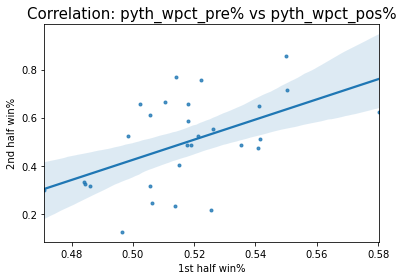

In [60]:
# Let's plot the variables and fit the model
sns.regplot(x='pyth_wpct_pre', y='win_pct_pos', data=NBA17_pos,  marker='.')
plt.xlabel('1st half win%')
plt.ylabel('2nd half win%')
plt.title("Correlation: pyth_wpct_pre% vs pyth_wpct_pos%", fontsize=15)

In [61]:
PythWin_lm = smf.ols(formula = 'win_pct_pos ~ pyth_wpct_pre', data=NBA17_pos).fit()
PythWin_lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            win_pct_pos   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     9.958
Date:                Thu, 30 Apr 2026   Prob (F-statistic):            0.00391
Time:                        11:33:38   Log-Likelihood:                 12.438
No. Observations:                  29   AIC:                            -20.88
Df Residuals:                      27   BIC:                            -18.14
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -1.6702      0.687     -2.430      0.022      -3.081      -0.260
pyth_wpct_pre     4.1898      1.328      3.156      0.004       1.466       6.914
==============================================================================
Omnibus:                        0.529   Durbin-Watson:                   2.705
Prob(Omnibus):                  0.768   Jarque-Bera (JB):                0.619
Skew:                          -0.100   Prob(JB):                        0.734
Kurtosis:                       2.312   Cond. No.                         55.5
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [62]:
from statsmodels.iolib.summary2 import summary_col
info_dict={'R-squared' : lambda x: f"{x.rsquared:.2f}"}
Header = ['1','2']
Table_1 = summary_col([WinPct_lm, PythWin_lm,],\
                      regressor_order=['Intercept','Win%','Pyth.Win%'], model_names = Header, info_dict=info_dict)
print(Table_1)


                 1        2    
-------------------------------
Intercept     0.1191   -1.6702 
              (0.1004) (0.6874)
R-squared     0.3396   0.2424  
              0.3632   0.2694  
pyth_wpct_pre          4.1898  
                       (1.3277)
win_pct_pre   0.7558           
              (0.1926)         
R-squared     0.36     0.27    
Standard errors in parentheses.
